In [11]:
import importlib, GallenModel_v1, Landslidev2_Old, metrics, train
from typing import Optional
importlib.reload(GallenModel_v1)
importlib.reload(Landslidev2_Old)
importlib.reload(metrics)
importlib.reload(train)
from train import train_model_folds, train_model_folds_no_pga_dce, train_model_folds_no_pga
from sklearn.metrics import confusion_matrix
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from data import dataframe_to_dataset
from imblearn.over_sampling import SMOTE
from imblearn import pipeline, under_sampling
import keras_tuner as kt
import sklearn
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import geopandas as gpd
import seaborn as sns
import pandas as pd
import contextily as cx
from data import NormalizationLayer
from metrics import plot_distribution, plot_susceptibility_map, plot_landslide_distribution, plot_confusion_matrix, calculate_distribution
from GallenModel_v1 import  NewmarkActivation, DisplacementLayer, LandslideActivationLayer, CohesionLayer, InternalFrictionLayer
from Landslidev2_Old import DiceCrossEntropyLoss

In [12]:
df = gpd.read_file('~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_15_Validation1.gpkg')
df.drop(columns=['landslide_probability', 'landslide_preds', 'confusion', 'sus_pinn_landslide', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction'], inplace=True)

In [13]:
df = df[df['Slope_mean'] >= 10]

In [14]:
columns = list(df.columns)
columns

['DN',
 'BD_mean',
 'Clay_mean',
 'Sand_mean',
 'Silt_mean',
 'NDVI_mean',
 'Est_mean',
 'Nrt_mean',
 'HorCurv_mean',
 'VertCurv_mean',
 'Slope_mean',
 'Elev_mean',
 'SoilThc_mean',
 'DistFlt_min',
 'LULC_majority',
 'TWI_mean',
 'PGA2_max',
 'PGA1_max',
 'Prc_mean',
 'Distrv_min',
 'distrd_min',
 'Soil Type',
 'BUK_mean',
 'landslide',
 'descriptio',
 'type',
 'geometry']

In [15]:
df.dropna(subset=list(columns), inplace=True) #cleans the dataframe by removing null rows for all columns

In [16]:
cols_remove = ['DN', 'BD_mean', 'geometry', 'PGA2_max', 'Soil Type', 'description', 'descriptio']
columns = [col for col in list(columns) if col not in cols_remove]
sampling_columns = [col for col in columns if col != 'landslide' and col != 'type']
columns

['Clay_mean',
 'Sand_mean',
 'Silt_mean',
 'NDVI_mean',
 'Est_mean',
 'Nrt_mean',
 'HorCurv_mean',
 'VertCurv_mean',
 'Slope_mean',
 'Elev_mean',
 'SoilThc_mean',
 'DistFlt_min',
 'LULC_majority',
 'TWI_mean',
 'PGA1_max',
 'Prc_mean',
 'Distrv_min',
 'distrd_min',
 'BUK_mean',
 'landslide',
 'type']

Text(0.5, 1.0, 'Landslide Data')

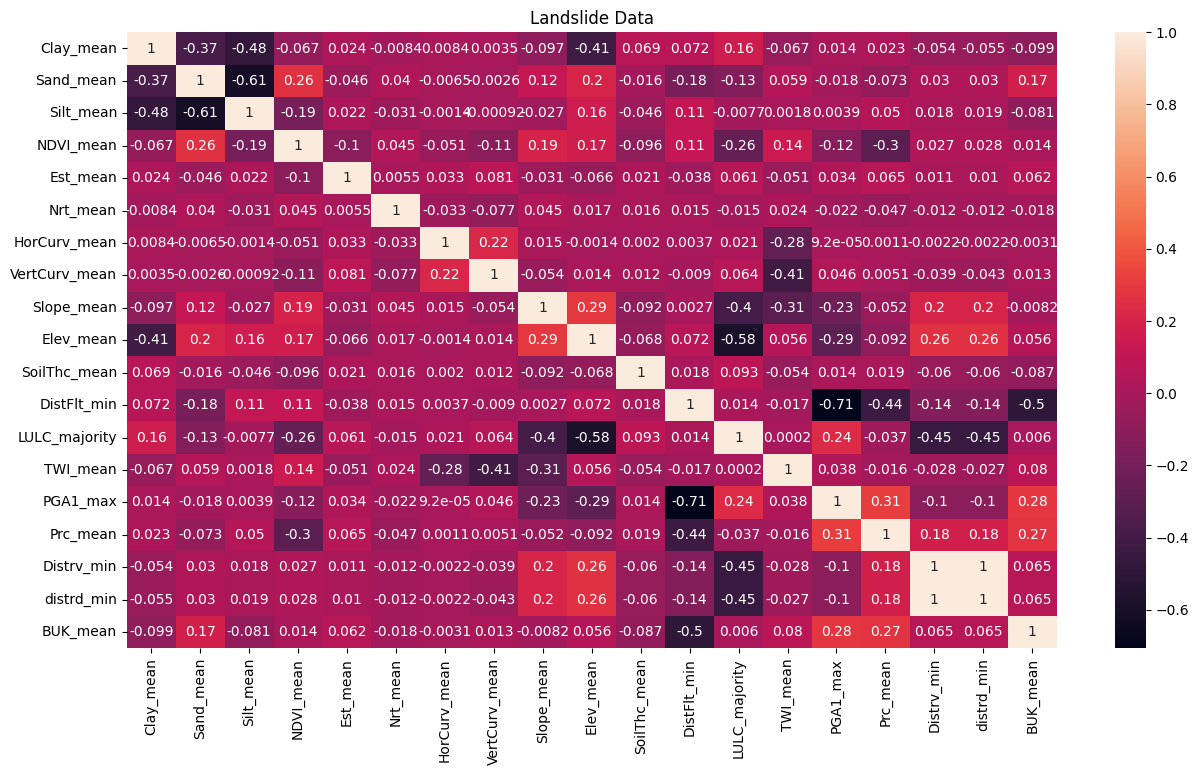

In [17]:
df[sampling_columns].corr()
plt.figure(figsize=(15, 8))
plot = sns.heatmap(df[sampling_columns].corr(), annot=True)
plot.set_title("Landslide Data")

In [18]:
model = load_model("/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v4-1-1dce/fold-4-model-0.keras")

In [19]:
validation_ds = dataframe_to_dataset(df[columns], shuffle=False)
susceptibility_prediction = model.predict(validation_ds)

7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 569us/step


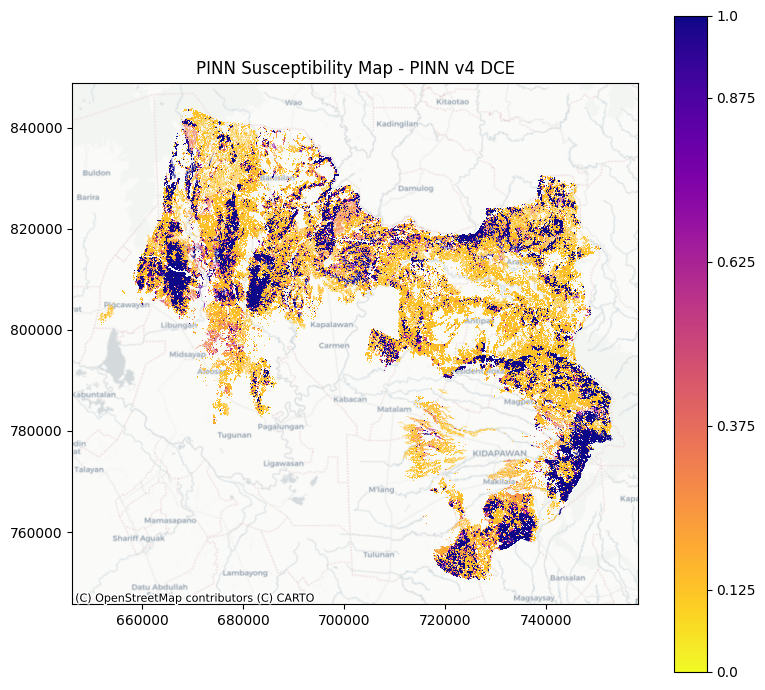

In [20]:
plot_susceptibility_map(df, susceptibility_prediction, "PINN v4 DCE")

7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 570us/step
Predicted cohesion length: 241062


(np.float32(0.0), np.float32(2.935861))

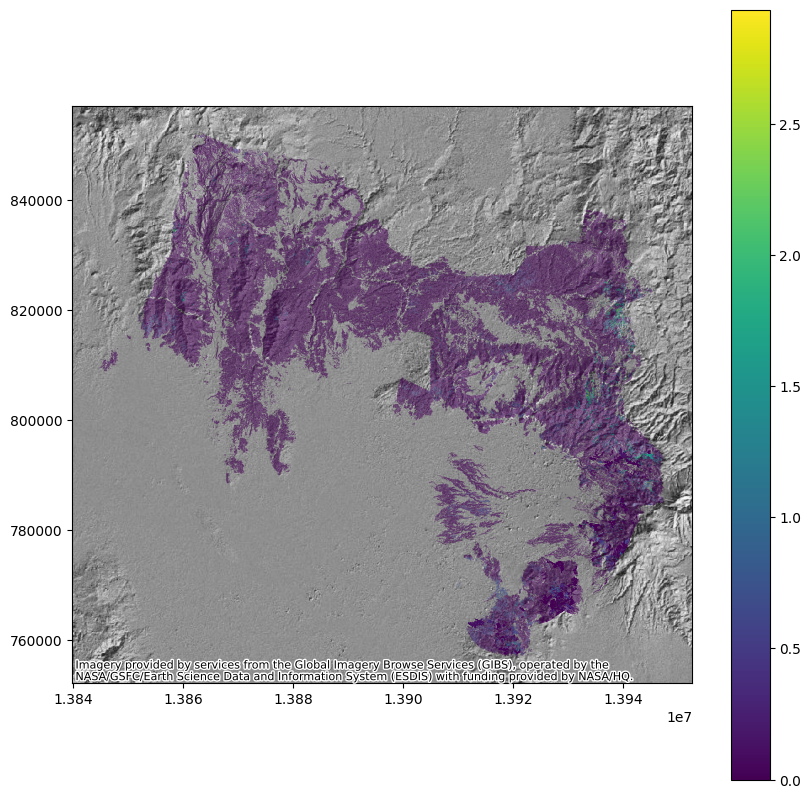

In [21]:
#Extract Geotechnical estimation of the model
df_wm = df.to_crs(epsg=3857)
cohesion_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("cohesion_layer").output)
predicted_cohesion = cohesion_model.predict(validation_ds)
df_wm['estimated_cohesion'] = predicted_cohesion

ax = df_wm.plot(column="estimated_cohesion", legend=True, figsize=(10, 10), alpha=0.7)
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
print(f"Predicted cohesion length: {len(predicted_cohesion)}")
df_wm['estimated_cohesion'].min(), df_wm['estimated_cohesion'].max()


7534/7534 ━━━━━━━━━━━━━━━━━━━━ 4s 551us/step


(np.float32(0.021542322), np.float32(0.9980173))

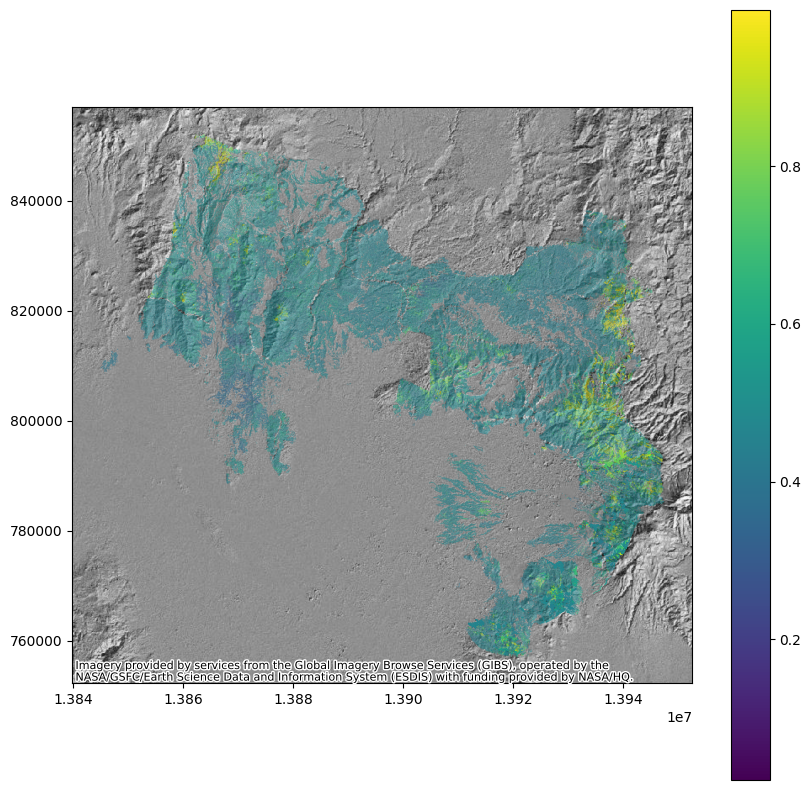

In [22]:
df_wm = df.to_crs(epsg=3857)
friction_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("internal_friction").output)
geotech_preds = friction_model.predict(validation_ds)
df_wm["ifi"] = geotech_preds
ax = df_wm.plot(column="ifi", legend=True, figsize=(10, 10), alpha=0.7)
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

df_wm['ifi'].min(), df_wm['ifi'].max()

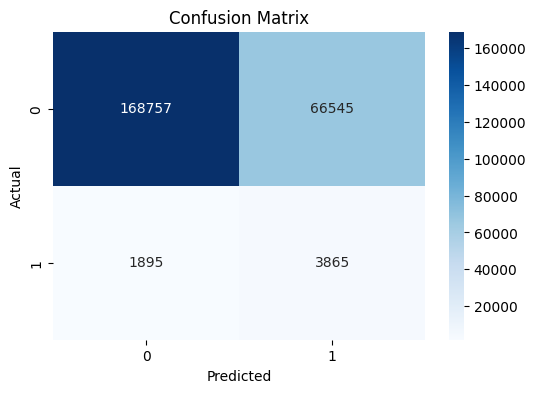

In [23]:
plot_confusion_matrix(susceptibility_prediction, df['landslide'])

In [24]:
result = calculate_distribution(df)
print(result)

{'0.125': 0, '0.375': 165404, '0.625': 174341, '0.875': 6735, '1.0': 16075}
